### **Setup Kaggle Step 1**





In [ ]:
!pip install -q kaggle

from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shamstahzib","key":"47b51843261918eb5d9a9f8d7487d1d3"}'}

### **Setup Kaggle Step 2**

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

### **CREATE DATA DIR/DOWNLOAD DATASETS**

In [ ]:
import os

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

print("Downloading datasets...")

!kaggle datasets download -d shamstahzib/nsl-kdd-dataset -p data
!kaggle datasets download -d shamstahzib/cicids2017-dataset -p data
!kaggle datasets download -d shamstahzib/ton-iot -p data

print("Download complete.")

Dataset URL: https://www.kaggle.com/datasets/shamstahzib/nsl-kdd-dataset
License(s): CC0-1.0
100% 13.6M/13.6M [00:00<00:00, 89.3MB/s]

Dataset URL: https://www.kaggle.com/datasets/shamstahzib/cicids2017-dataset
License(s): CC0-1.0
100% 230M/230M [00:02<00:00, 87.7MB/s]

Dataset URL: https://www.kaggle.com/datasets/shamstahzib/ton-iot
License(s): unknown
100% 1.68M/1.68M [00:00<00:00, 22.0MB/s]

Download complete.


### **EXTRACT FILES**

In [ ]:
import zipfile

print("Extracting datasets...")

for file in os.listdir(DATA_DIR):
    if file.endswith(".zip"):
        path = os.path.join(DATA_DIR, file)
        print("Extracting:", file)
        with zipfile.ZipFile(path, 'r') as zip_ref:
            zip_ref.extractall(DATA_DIR)

print("Extraction complete.")

Extracting datasets...
Extracting: ton-iot.zip
Extracting: nsl-kdd-dataset.zip
Extracting: cicids2017-dataset.zip
Extraction complete.


### **VERIFY STRUCTURE**

In [ ]:
print("\nData directory structure:")

for root, dirs, files in os.walk(DATA_DIR):
    print(root, "->", len(files), "files")


Data directory structure:
data -> 3 files
data/nsl-kdd-dataset -> 12 files
data/nsl-kdd-dataset/Original NSL KDD Zip -> 8 files
data/kaggle_upload -> 0 files
data/kaggle_upload/Train_Test_IoT_dataset -> 7 files
data/CICIDS2017 -> 8 files


### **LOAD**

In [ ]:
import pandas as pd
import numpy as np
import glob, os, warnings
warnings.filterwarnings("ignore")

# ---------- LOAD ----------
print("\n[+] Loading NSL-KDD...")
nsl_path = None
for root, _, files in os.walk("data"):
    for f in files:
        if "KDDTrain" in f:
            nsl_path = os.path.join(root, f)
nsl = pd.read_csv(nsl_path, header=None)
nsl["label"] = nsl.iloc[:, -2]
print("NSL raw:", nsl.shape)

print("\n[+] Loading CICIDS2017...")
cic_files = glob.glob("data/CICIDS2017/*.csv")
cic = pd.concat([pd.read_csv(f, nrows=60000, low_memory=False) for f in cic_files], ignore_index=True)
cic.columns = cic.columns.str.strip()
print("CIC raw:", cic.shape)

print("\n[+] Loading TON_IoT...")
ton_files = glob.glob("data/**/Train_Test_IoT_dataset/*.csv", recursive=True)
ton = pd.concat([pd.read_csv(f, nrows=60000, low_memory=False) for f in ton_files], ignore_index=True)
ton.columns = ton.columns.str.strip()
print("TON raw:", ton.shape)


[+] Loading NSL-KDD...
NSL raw: (25192, 44)

[+] Loading CICIDS2017...
CIC raw: (480000, 79)

[+] Loading TON_IoT...
TON raw: (261119, 21)


### **LABEL MAPS**

In [ ]:
def map_nsl(x):
    x = str(x).lower()
    if x == "normal": return "Normal"
    if x in ["neptune","smurf","back","teardrop","pod","land"]: return "DoS"
    if x in ["satan","ipsweep","nmap","portsweep"]: return "Probe"
    if x in ["warezclient","ftp_write","guess_passwd","imap"]: return "R2L"
    if x in ["buffer_overflow","rootkit","loadmodule"]: return "U2R"
    return None

def map_cic(x):
    x = str(x).lower()
    if "benign" in x: return "Normal"
    if "dos" in x or "ddos" in x: return "DoS"
    if "scan" in x: return "Probe"
    return None

def map_ton(x):
    if x == 0: return "Normal"
    if x == 1: return "DoS"
    return None


### **CLEAN**

In [ ]:
def clean_df(df, mapper):
    df.columns = df.columns.astype(str).str.strip()
    label_col = "Label" if "Label" in df.columns else ("label" if "label" in df.columns else df.columns[-1])
    print("  Label col:", label_col)
    df = df.copy()
    df["label"] = df[label_col].apply(mapper)
    df = df[df["label"].notna()]
    numeric = df.select_dtypes(include=["int64","float64"]).copy()
    numeric = numeric.replace([np.inf, -np.inf], 0).fillna(0)
    numeric["label"] = df["label"].values
    return numeric

print("\n[+] Cleaning...")
clean_nsl = clean_df(nsl, map_nsl)
clean_cic = clean_df(cic, map_cic)
clean_ton = clean_df(ton, map_ton)
print("Shapes:", clean_nsl.shape, clean_cic.shape, clean_ton.shape)

# ---------- ALIGN ----------
print("\n[+] Aligning features...")
all_cols = (set(clean_nsl.columns) | set(clean_cic.columns) | set(clean_ton.columns)) - {"label"}

def unify(df):
    return df.reindex(columns=sorted(all_cols) + ["label"]).fillna(0)

u_nsl = unify(clean_nsl)
u_cic = unify(clean_cic)
u_ton = unify(clean_ton)


[+] Cleaning...
  Label col: label
  Label col: Label
  Label col: label
Shapes: (25180, 40) (471902, 79) (261119, 14)

[+] Aligning features...


### **MERGE**

In [ ]:
merged = pd.concat([u_nsl, u_cic, u_ton], ignore_index=True)
print("Merged:", merged.shape)

Merged: (758201, 131)


### **BALANCE**

In [ ]:
print("\n[+] Balancing to 20,000 per class...")
CLASSES = ["Normal","DoS","Probe","R2L","U2R"]
TARGET  = 20000
final   = []
for c in CLASSES:
    part = merged[merged["label"] == c]
    n    = len(part)
    if n >= TARGET:
        final.append(part.sample(TARGET, random_state=42))
    else:
        final.append(part.sample(TARGET, replace=True, random_state=42))

final_df = pd.concat(final, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(final_df["label"].value_counts())

final_df.to_csv("Final_5Class_IDS.csv", index=False)
print("\n Saved Final_5Class_IDS.csv")



[+] Balancing to 20,000 per class...
label
R2L       20000
U2R       20000
Normal    20000
Probe     20000
DoS       20000
Name: count, dtype: int64

 Saved Final_5Class_IDS.csv


### **FEDERATED TRAINING**

In [ ]:
import pandas as pd, numpy as np, warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import xgboost as xgb

# ---------- LOAD ----------
print("Loading dataset...")
df = pd.read_csv("Final_5Class_IDS.csv")

X_raw = df.drop(columns=["label"])
y_raw = df["label"]

# keep only informative features
X_raw = X_raw.loc[:, X_raw.nunique() > 1]
X_raw = X_raw.replace([np.inf, -np.inf], 0).fillna(0).clip(-1e6, 1e6)

le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
n_classes = len(np.unique(y_enc))
CLASS_NAMES = list(le.classes_)
print("Classes:", CLASS_NAMES)
print("Feature count:", X_raw.shape[1])

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_raw)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
RESULTS = {}

# ---------- DEGRADATION LEVELS ----------
DRIFT_CFG = {
    "NO DRIFT":     dict(noise=0.00, blackout=0.00, flip=0.00),
    "MILD DRIFT":   dict(noise=0.04, blackout=0.08, flip=0.02),
    "SEVERE DRIFT": dict(noise=0.08, blackout=0.12, flip=0.04),
}

def degrade(X, y, cid, cfg):
    """Apply controlled degradation to simulate client-side drift."""
    X = X.copy(); y = y.copy()
    if cfg["noise"] > 0:
        scale = cfg["noise"] * (1 + 0.5 * cid)          # Client 2 slightly worse
        X += np.random.normal(0, scale, X.shape)
    if cfg["blackout"] > 0:
        n_feat = int(X.shape[1] * cfg["blackout"] * (1 + 0.3 * cid))
        X[:, :n_feat] = 0
    if cfg["flip"] > 0:
        ratio = cfg["flip"] * (1 + 0.5 * cid)
        n_flip = int(len(y) * ratio)
        idx = np.random.choice(len(y), n_flip, replace=False)
        y[idx] = np.random.randint(0, n_classes, size=n_flip)
    return X, y

def build_model(cid, cfg):
    """Stronger model for clean client; lighter for degraded clients."""
    if cid == 0 or cfg["noise"] == 0:
        return xgb.XGBClassifier(
            objective="multi:softprob", num_class=n_classes,
            n_estimators=150, max_depth=7,
            learning_rate=0.05, subsample=0.9,
            colsample_bytree=0.9, min_child_weight=1,
            tree_method="hist", verbosity=0, random_state=42
        )
    else:
        return xgb.XGBClassifier(
            objective="multi:softprob", num_class=n_classes,
            n_estimators=100, max_depth=5,
            learning_rate=0.08, subsample=0.75,
            colsample_bytree=0.75, min_child_weight=3,
            tree_method="hist", verbosity=0, random_state=42
        )

def run_experiment(scenario_name):
    cfg = DRIFT_CFG[scenario_name]
    print(f"\n{'='*50}")
    print(f"  Scenario: {scenario_name}")
    print(f"{'='*50}")

    accs, f1s, trust_logs      = [], [], []
    all_true, all_preds, all_probs = [], [], []

    for fold, (tr, te) in enumerate(skf.split(X_sc, y_enc), 1):
        Xtr, Xte = X_sc[tr], X_sc[te]
        ytr, yte = y_enc[tr], y_enc[te]

        splits = np.array_split(range(len(Xtr)), 3)   # 3 federated clients
        models, trust_scores = [], []

        for cid, idx in enumerate(splits):
            X_loc = Xtr[idx]; y_loc = ytr[idx]

            # ensure all classes present
            for c in range(n_classes):
                if c not in y_loc:
                    X_loc = np.vstack([X_loc, np.zeros(X_loc.shape[1])])
                    y_loc = np.append(y_loc, c)

            # train/val split for trust score
            X_tr, X_val, y_tr, y_val = train_test_split(
                X_loc, y_loc, test_size=0.2,
                stratify=y_loc, random_state=fold
            )

            # apply drift only to clients 1 & 2
            if cid > 0:
                X_tr, y_tr = degrade(X_tr, y_tr, cid, cfg)

            model = build_model(cid, cfg)
            model.fit(X_tr, y_tr)

            trust = accuracy_score(y_val, np.argmax(model.predict_proba(X_val), axis=1))
            trust_scores.append(trust)
            models.append(model)
            print(f"  Fold {fold} | Client {cid} | Trust: {trust:.4f}")

        # trust-weighted aggregation
        w = np.array(trust_scores)
        w = w / (w.sum() + 1e-9)

        probs = [m.predict_proba(Xte) for m in models]
        final = sum(wi * p for wi, p in zip(w, probs))
        pred  = np.argmax(final, axis=1)

        acc = accuracy_score(yte, pred)
        f1  = f1_score(yte, pred, average="weighted")
        print(f"  >>> Fold {fold}: ACC={acc:.4f} | F1={f1:.4f}")

        accs.append(acc); f1s.append(f1)
        trust_logs.append(trust_scores)
        all_true.extend(yte); all_preds.extend(pred); all_probs.extend(final)

    mean_acc = np.mean(accs)
    mean_f1  = np.mean(f1s)
    print(f"\n  MEAN ACC = {mean_acc:.4f}  |  MEAN F1 = {mean_f1:.4f}")

    RESULTS[scenario_name] = {
        "accs":    accs,     "f1s":    f1s,
        "trust":   trust_logs,
        "mean_acc": mean_acc, "mean_f1": mean_f1,
        "y_true":  np.array(all_true),
        "y_pred":  np.array(all_preds),
        "y_probs": np.array(all_probs),
    }

# ---------- RUN ----------
run_experiment("NO DRIFT")
run_experiment("MILD DRIFT")
run_experiment("SEVERE DRIFT")

# ---------- SUMMARY ----------
print("\n" + "="*50)
print("  ABLATION SUMMARY")
print("="*50)
for s in ["NO DRIFT","MILD DRIFT","SEVERE DRIFT"]:
    r = RESULTS[s]
    print(f"  {s:<14}  ACC={r['mean_acc']:.4f}  F1={r['mean_f1']:.4f}")


Loading dataset...
Classes: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']
Feature count: 116

  Scenario: NO DRIFT
  Fold 1 | Client 0 | Trust: 0.9657
  Fold 1 | Client 1 | Trust: 0.9678
  Fold 1 | Client 2 | Trust: 0.9610
  >>> Fold 1: ACC=0.9658 | F1=0.9656
  Fold 2 | Client 0 | Trust: 0.9685
  Fold 2 | Client 1 | Trust: 0.9659
  Fold 2 | Client 2 | Trust: 0.9629
  >>> Fold 2: ACC=0.9638 | F1=0.9636
  Fold 3 | Client 0 | Trust: 0.9666
  Fold 3 | Client 1 | Trust: 0.9648
  Fold 3 | Client 2 | Trust: 0.9606
  >>> Fold 3: ACC=0.9664 | F1=0.9661
  Fold 4 | Client 0 | Trust: 0.9679
  Fold 4 | Client 1 | Trust: 0.9661
  Fold 4 | Client 2 | Trust: 0.9601
  >>> Fold 4: ACC=0.9656 | F1=0.9653
  Fold 5 | Client 0 | Trust: 0.9642
  Fold 5 | Client 1 | Trust: 0.9633
  Fold 5 | Client 2 | Trust: 0.9642
  >>> Fold 5: ACC=0.9657 | F1=0.9655

  MEAN ACC = 0.9655  |  MEAN F1 = 0.9652

  Scenario: MILD DRIFT
  Fold 1 | Client 0 | Trust: 0.9657
  Fold 1 | Client 1 | Trust: 0.9597
  Fold 1 | Client 2 | Trust

### **EDA VISUALIZATIONS**

Dataset shape: (100000, 131)


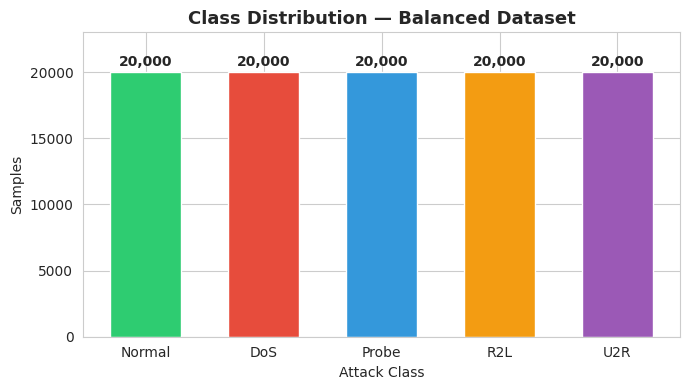

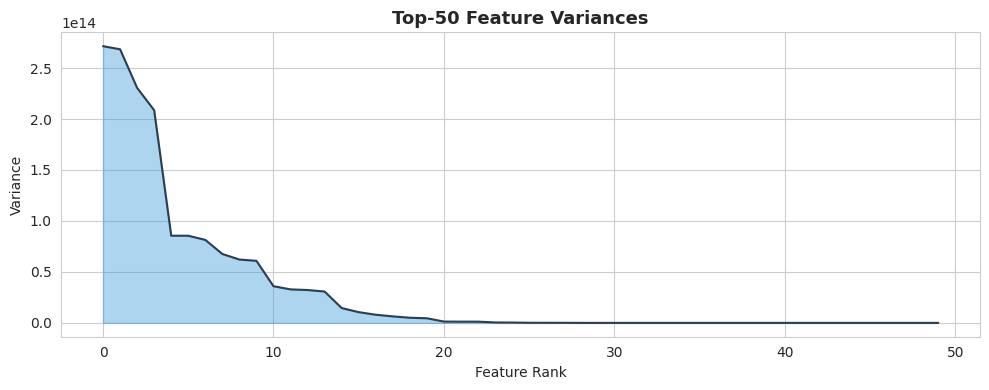

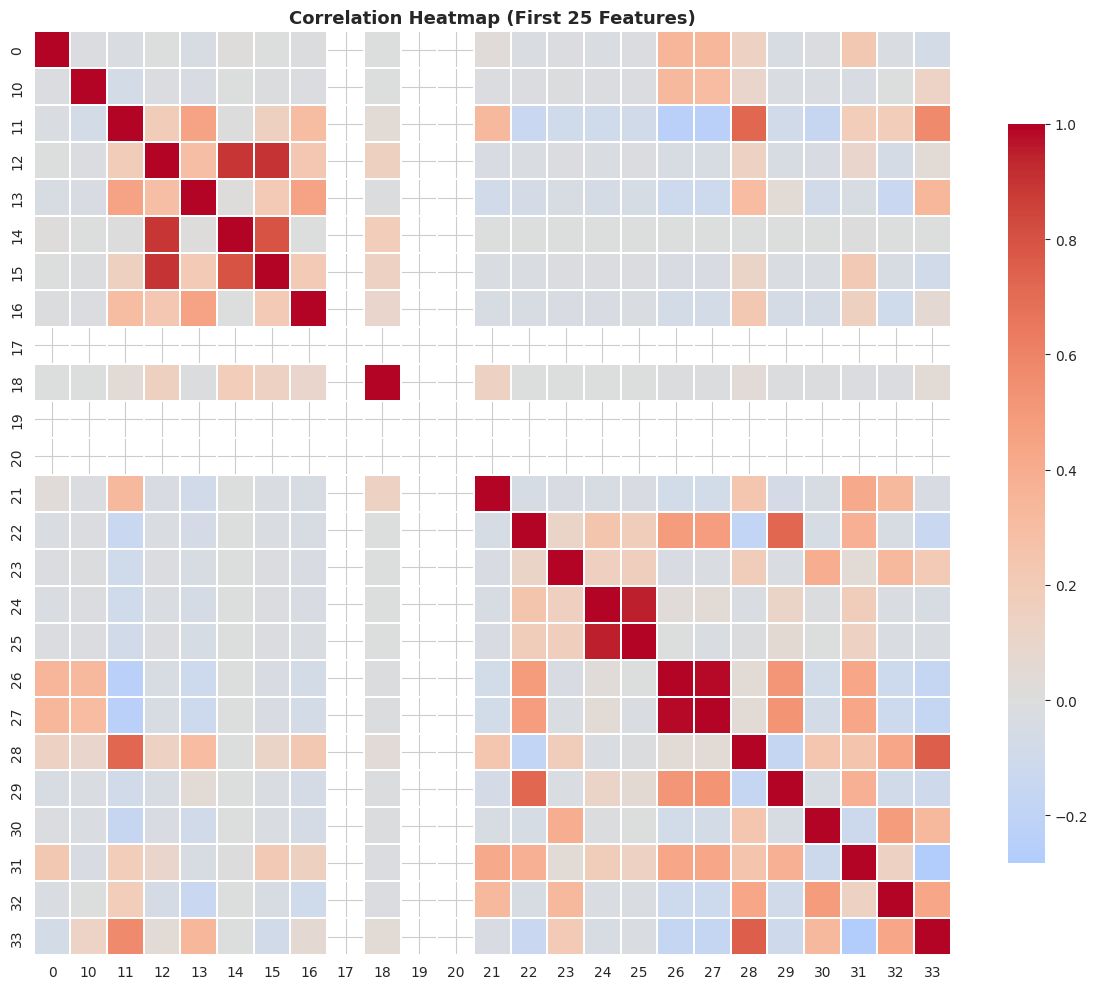

Running PCA...


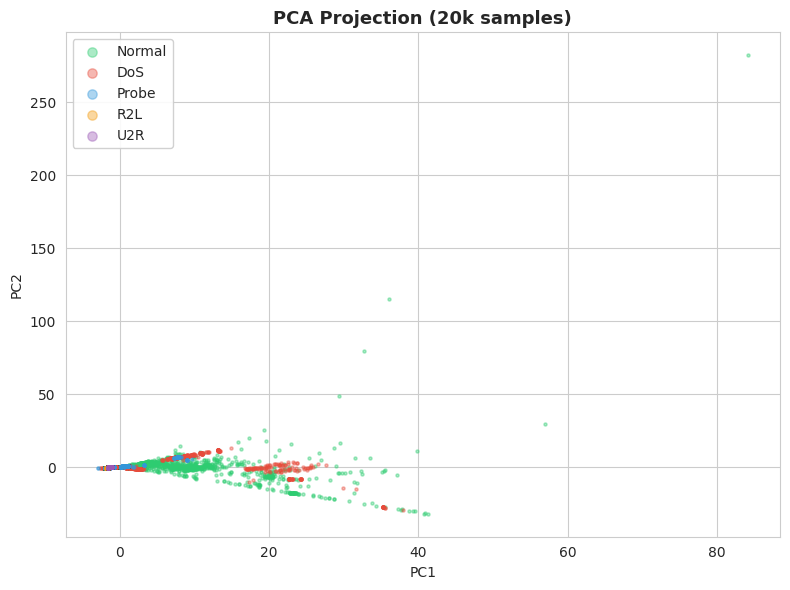

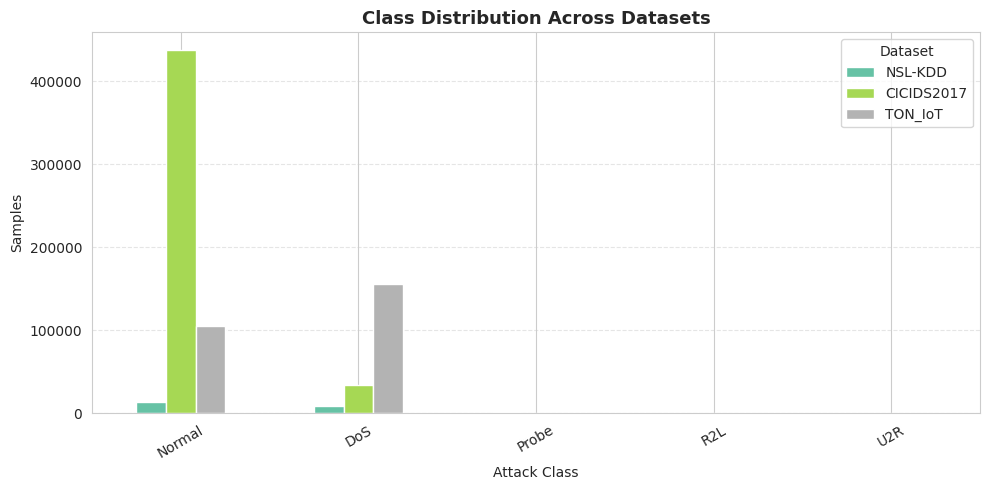

 EDA visualizations complete.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
PALETTE = {"Normal":"#2ecc71","DoS":"#e74c3c","Probe":"#3498db","R2L":"#f39c12","U2R":"#9b59b6"}

df = pd.read_csv("Final_5Class_IDS.csv")
numeric_df = df.drop(columns=["label"])

print("Dataset shape:", df.shape)

# --- 1. CLASS DISTRIBUTION ---
fig, ax = plt.subplots(figsize=(7, 4))
counts = df["label"].value_counts().reindex(CLASSES)
bars   = ax.bar(counts.index, counts.values,
                color=[PALETTE[c] for c in counts.index], edgecolor="white", width=0.6)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Class Distribution — Balanced Dataset", fontsize=13, fontweight="bold")
ax.set_xlabel("Attack Class"); ax.set_ylabel("Samples")
ax.set_ylim(0, 23000)
plt.tight_layout(); plt.savefig("fig_class_dist.png", dpi=150); plt.show()

# --- 2. TOP-50 FEATURE VARIANCE ---
variances = numeric_df.var().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(range(50), variances.values[:50], alpha=0.4, color="#3498db")
ax.plot(variances.values[:50], color="#2c3e50", linewidth=1.5)
ax.set_title("Top-50 Feature Variances", fontsize=13, fontweight="bold")
ax.set_xlabel("Feature Rank"); ax.set_ylabel("Variance")
plt.tight_layout(); plt.savefig("fig_variance.png", dpi=150); plt.show()

# --- 3. CORRELATION HEATMAP ---
subset = numeric_df.columns[:25]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(numeric_df[subset].corr(), cmap="coolwarm", center=0,
            linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap (First 25 Features)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("fig_corr.png", dpi=150); plt.show()

# --- 4. PCA SCATTER ---
print("Running PCA...")
sample     = numeric_df.sample(20000, random_state=42)
X_sc       = StandardScaler().fit_transform(sample)
pca_result = PCA(n_components=2).fit_transform(X_sc)

df_pca = pd.DataFrame({
    "PC1": pca_result[:,0],
    "PC2": pca_result[:,1],
    "label": df.loc[sample.index, "label"].values
})

fig, ax = plt.subplots(figsize=(8, 6))
for cls in CLASSES:
    sub = df_pca[df_pca["label"] == cls]
    ax.scatter(sub["PC1"], sub["PC2"], s=5, alpha=0.4,
               color=PALETTE[cls], label=cls)
ax.set_title("PCA Projection (20k samples)", fontsize=13, fontweight="bold")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(markerscale=3, framealpha=0.9)
plt.tight_layout(); plt.savefig("fig_pca.png", dpi=150); plt.show()

# --- 5. CROSS-DATASET DISTRIBUTION ---
all_cls_order = ["Normal","DoS","Probe","R2L","U2R"]
counts_dict = {
    "NSL-KDD":    clean_nsl["label"].value_counts().reindex(all_cls_order, fill_value=0),
    "CICIDS2017": clean_cic["label"].value_counts().reindex(all_cls_order, fill_value=0),
    "TON_IoT":    clean_ton["label"].value_counts().reindex(all_cls_order, fill_value=0),
}
df_plot = pd.DataFrame(counts_dict)
ax = df_plot.plot(kind="bar", figsize=(10, 5), colormap="Set2", edgecolor="white")
ax.set_title("Class Distribution Across Datasets", fontsize=13, fontweight="bold")
ax.set_xlabel("Attack Class"); ax.set_ylabel("Samples")
plt.xticks(rotation=30)
plt.legend(title="Dataset")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout(); plt.savefig("fig_cross_dist.png", dpi=150); plt.show()

print(" EDA visualizations complete.")

## **RESULTS VISUALIZATIONS**

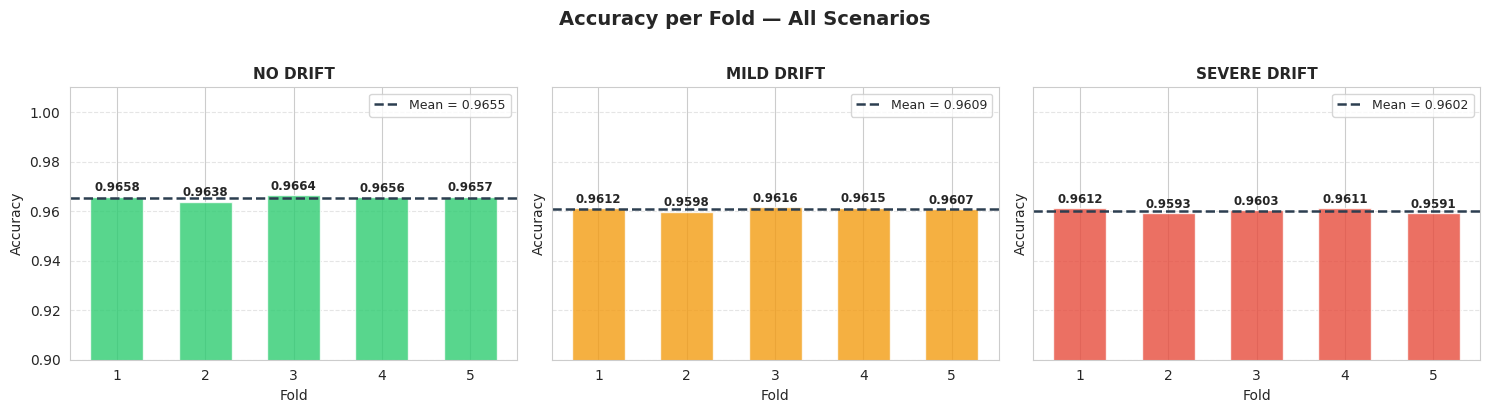

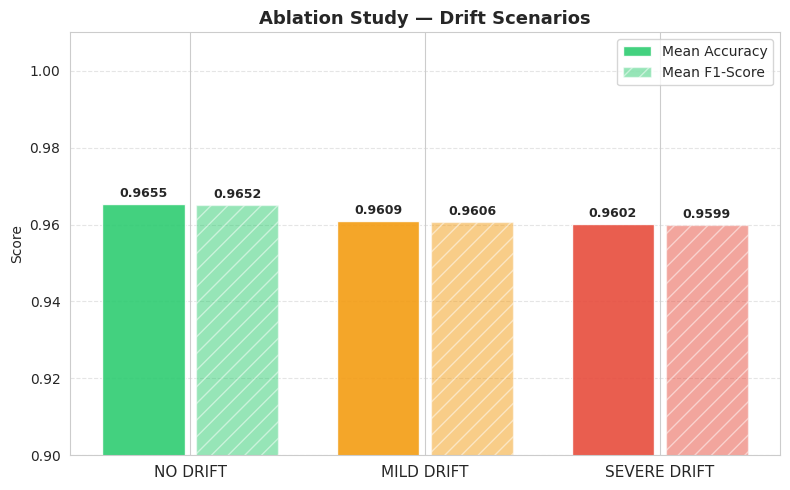

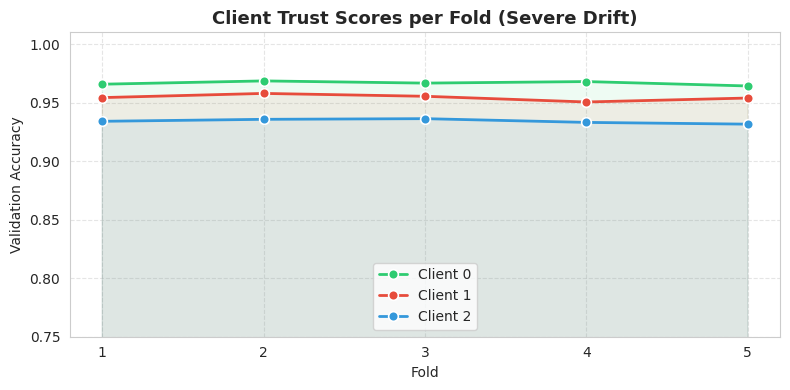

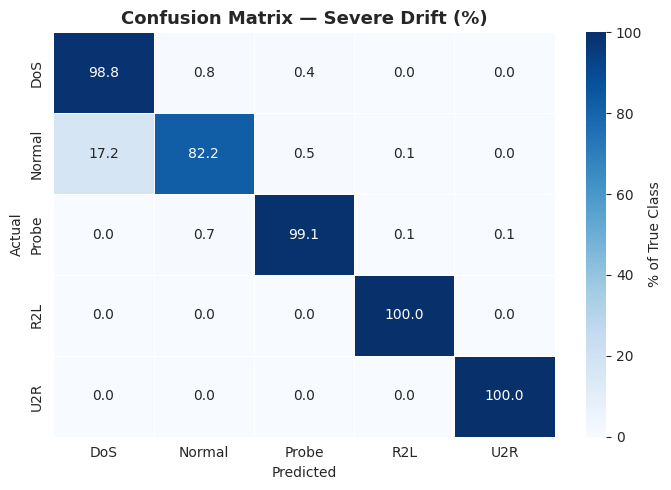

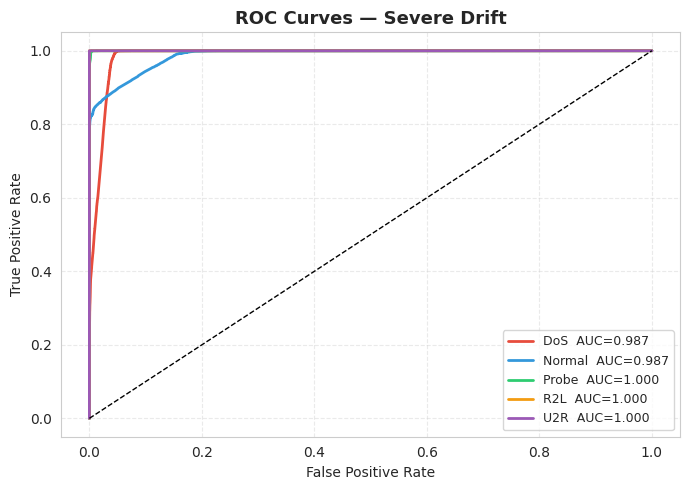

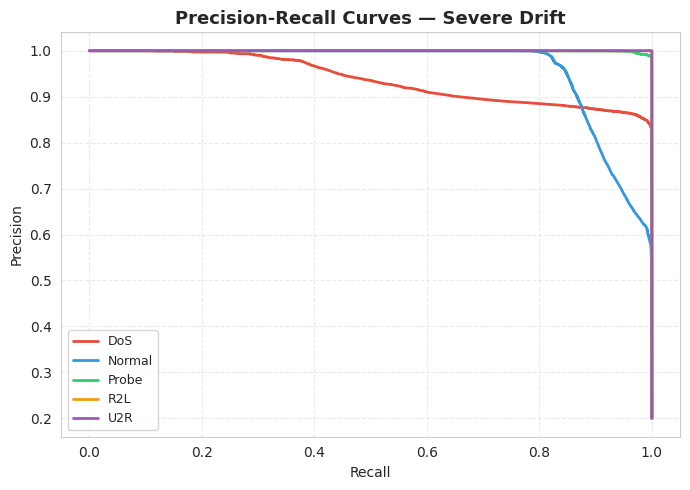


SCENARIO                                        FOLD ACCS   MEAN
NO DRIFT         0.9658  0.9638  0.9664  0.9656  0.9657   0.9655
MILD DRIFT       0.9612  0.9598  0.9616  0.9615  0.9607   0.9609
SEVERE DRIFT     0.9612  0.9593  0.9603  0.9611  0.9591   0.9602


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

sns.set_style("whitegrid")
SCEN_COLORS = {"NO DRIFT":"#2ecc71","MILD DRIFT":"#f39c12","SEVERE DRIFT":"#e74c3c"}
SCENARIOS   = ["NO DRIFT","MILD DRIFT","SEVERE DRIFT"]

# ─────────────────────────────────────────────
# FIG 1 — ACCURACY PER FOLD (all 3 scenarios)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Accuracy per Fold — All Scenarios", fontsize=14, fontweight="bold", y=1.02)

for ax, s in zip(axes, SCENARIOS):
    accs     = RESULTS[s]["accs"]
    mean_acc = RESULTS[s]["mean_acc"]
    folds    = range(1, len(accs)+1)
    bars     = ax.bar(folds, accs, color=SCEN_COLORS[s], alpha=0.8, edgecolor="white", width=0.6)
    ax.axhline(mean_acc, color="#2c3e50", linewidth=1.8, linestyle="--",
               label=f"Mean = {mean_acc:.4f}")
    for bar, v in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{v:.4f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
    ax.set_title(s, fontsize=11, fontweight="bold")
    ax.set_xlabel("Fold"); ax.set_ylabel("Accuracy")
    ax.set_ylim(0.90, 1.01)
    ax.set_xticks(folds)
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("fig_fold_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────
# FIG 2 — ABLATION STUDY (mean ACC + F1)
# ─────────────────────────────────────────────
mean_accs = [RESULTS[s]["mean_acc"] for s in SCENARIOS]
mean_f1s  = [RESULTS[s]["mean_f1"]  for s in SCENARIOS]
x         = np.arange(len(SCENARIOS))

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - 0.2, mean_accs, width=0.35, label="Mean Accuracy",
            color=[SCEN_COLORS[s] for s in SCENARIOS], alpha=0.9, edgecolor="white")
b2 = ax.bar(x + 0.2, mean_f1s,  width=0.35, label="Mean F1-Score",
            color=[SCEN_COLORS[s] for s in SCENARIOS], alpha=0.5, edgecolor="white",
            hatch="//")
for bar, v in [(b, val) for bars, vals in [(b1, mean_accs),(b2, mean_f1s)]
               for b, val in zip(bars, vals)]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{v:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(SCENARIOS, fontsize=11)
ax.set_ylim(0.90, 1.01)
ax.set_title("Ablation Study — Drift Scenarios", fontsize=13, fontweight="bold")
ax.set_ylabel("Score"); ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("fig_ablation.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# FIG 3 — TRUST SCORES ACROSS FOLDS (Severe)
# ─────────────────────────────────────────────
trust_logs  = RESULTS["SEVERE DRIFT"]["trust"]
client_cols = ["#2ecc71","#e74c3c","#3498db"]

fig, ax = plt.subplots(figsize=(8, 4))
for cid in range(3):
    vals = [t[cid] for t in trust_logs]
    ax.plot(range(1,6), vals, marker="o", linewidth=2,
            color=client_cols[cid], label=f"Client {cid}",
            markersize=7, markeredgecolor="white", markeredgewidth=1.2)
    ax.fill_between(range(1,6), vals, alpha=0.08, color=client_cols[cid])
ax.set_title("Client Trust Scores per Fold (Severe Drift)", fontsize=13, fontweight="bold")
ax.set_xlabel("Fold"); ax.set_ylabel("Validation Accuracy")
ax.set_xticks(range(1,6)); ax.set_ylim(0.75, 1.01)
ax.legend(); ax.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("fig_trust.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# FIG 4 — CONFUSION MATRIX (Severe Drift)
# ─────────────────────────────────────────────
y_true = RESULTS["SEVERE DRIFT"]["y_true"]
y_pred = RESULTS["SEVERE DRIFT"]["y_pred"]
y_prob = RESULTS["SEVERE DRIFT"]["y_probs"]
cm     = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax, cbar_kws={"label":"% of True Class"})
ax.set_title("Confusion Matrix — Severe Drift (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("fig_confmat.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# FIG 5 — ROC CURVES (Severe Drift)
# ─────────────────────────────────────────────
y_bin  = label_binarize(y_true, classes=np.arange(n_classes))
colors = ["#e74c3c","#3498db","#2ecc71","#f39c12","#9b59b6"]

fig, ax = plt.subplots(figsize=(7, 5))
for i, cname in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=colors[i],
            label=f"{cname}  AUC={roc_auc:.3f}")
ax.plot([0,1],[0,1],"k--", linewidth=1)
ax.set_title("ROC Curves — Severe Drift", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=9)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_roc.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# FIG 6 — PRECISION-RECALL CURVES (Severe Drift)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for i, cname in enumerate(CLASS_NAMES):
    p, r, _ = precision_recall_curve(y_bin[:, i], y_prob[:, i])
    ax.plot(r, p, linewidth=2, color=colors[i], label=cname)
ax.set_title("Precision-Recall Curves — Severe Drift", fontsize=13, fontweight="bold")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(fontsize=9); ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_pr.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# PRINT FINAL SUMMARY TABLE
# ─────────────────────────────────────────────
print("\n" + "="*60)
print(f"{'SCENARIO':<16} {'FOLD ACCS':>40}   MEAN")
print("="*60)
for s in SCENARIOS:
    fold_str = "  ".join([f"{a:.4f}" for a in RESULTS[s]["accs"]])
    print(f"{s:<16} {fold_str}   {RESULTS[s]['mean_acc']:.4f}")
print("="*60)
